Shape: (29994, 19)
MSE modelo lineal: 0.010456299824304795


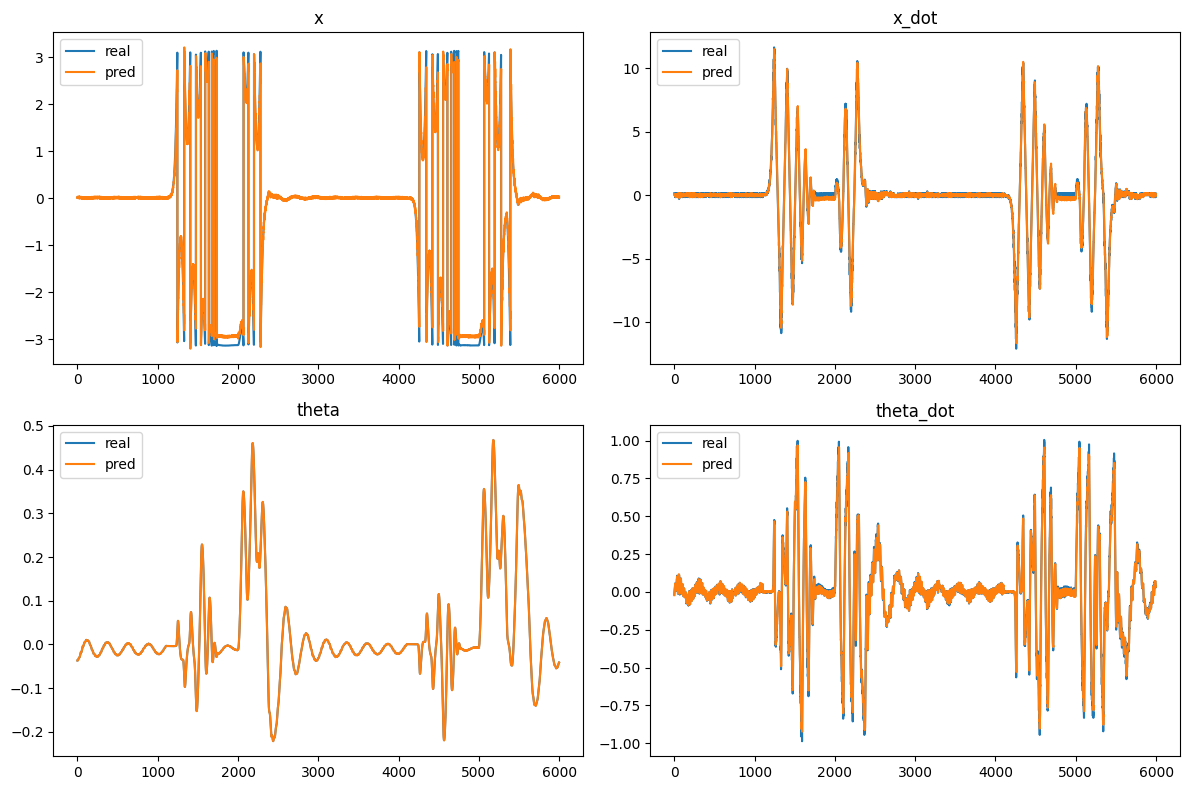

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# =========================
# 1. CARGAR DATASET
# =========================
df = pd.read_csv("../data/real/dataset_3_total.csv")

# =========================
# 2. LIMPIAR CABECERAS DUPLICADAS
# =========================
df = df[df["x_k"] != "x_k"]  # elimina cabeceras repetidas

# convertir a numérico
df = df.apply(pd.to_numeric)

print("Shape:", df.shape)

# =========================
# 3. SEPARAR X e Y
# =========================
Y = df[["x_k", "x_dot_k", "theta_k", "theta_dot_k"]].values
X = df.drop(columns=["x_k", "x_dot_k", "theta_k", "theta_dot_k"]).values

# =========================
# 4. SPLIT TEMPORAL
# =========================
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# =========================
# 5. NORMALIZACIÓN
# =========================
sx = StandardScaler()
sy = StandardScaler()

X_train = sx.fit_transform(X_train)
X_test = sx.transform(X_test)

Y_train = sy.fit_transform(Y_train)
Y_test = sy.transform(Y_test)

# =========================
# 6. MODELO LINEAL
# =========================
model = LinearRegression()
model.fit(X_train, Y_train)

# =========================
# 7. PREDICCIÓN
# =========================
Y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred)
print("MSE modelo lineal:", mse)

# =========================
# 8. DESNORMALIZAR
# =========================
Y_test_real = sy.inverse_transform(Y_test)
Y_pred_real = sy.inverse_transform(Y_pred)

# =========================
# 9. PLOT
# =========================
labels = ["x", "x_dot", "theta", "theta_dot"]

plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(Y_test_real[:,i], label="real")
    plt.plot(Y_pred_real[:,i], label="pred")
    plt.title(labels[i])
    plt.legend()

plt.tight_layout()
plt.show()

## Modelo de regresión lineal (baseline)

En esta sección se entrena un modelo de regresión lineal para aproximar la dinámica del sistema carrito-péndulo.

Se utiliza un dataset construido mediante un enfoque NARX, donde las entradas del modelo incluyen retardos de las variables de estado y de la señal de control. En concreto, se emplea un dataset combinado que agrupa diferentes tipos de excitación (chirp, random y control) con 3 retardos, lo que permite mejorar la capacidad de generalización del modelo.

El objetivo de este modelo es servir como referencia (baseline) para evaluar posteriormente modelos más complejos, como redes neuronales. Aunque el sistema es no lineal, la regresión lineal permite obtener una primera aproximación de su comportamiento en predicción a un paso.

A continuación, se realiza:
- Carga y limpieza del dataset (eliminando cabeceras duplicadas)
- Separación en variables de entrada (X) y salida (Y)
- División temporal en conjunto de entrenamiento y test
- Normalización de los datos
- Entrenamiento del modelo lineal
- Evaluación mediante el error cuadrático medio (MSE)
- Visualización de las predicciones frente a los valores reales

MSE MLP: 0.010107814819415981


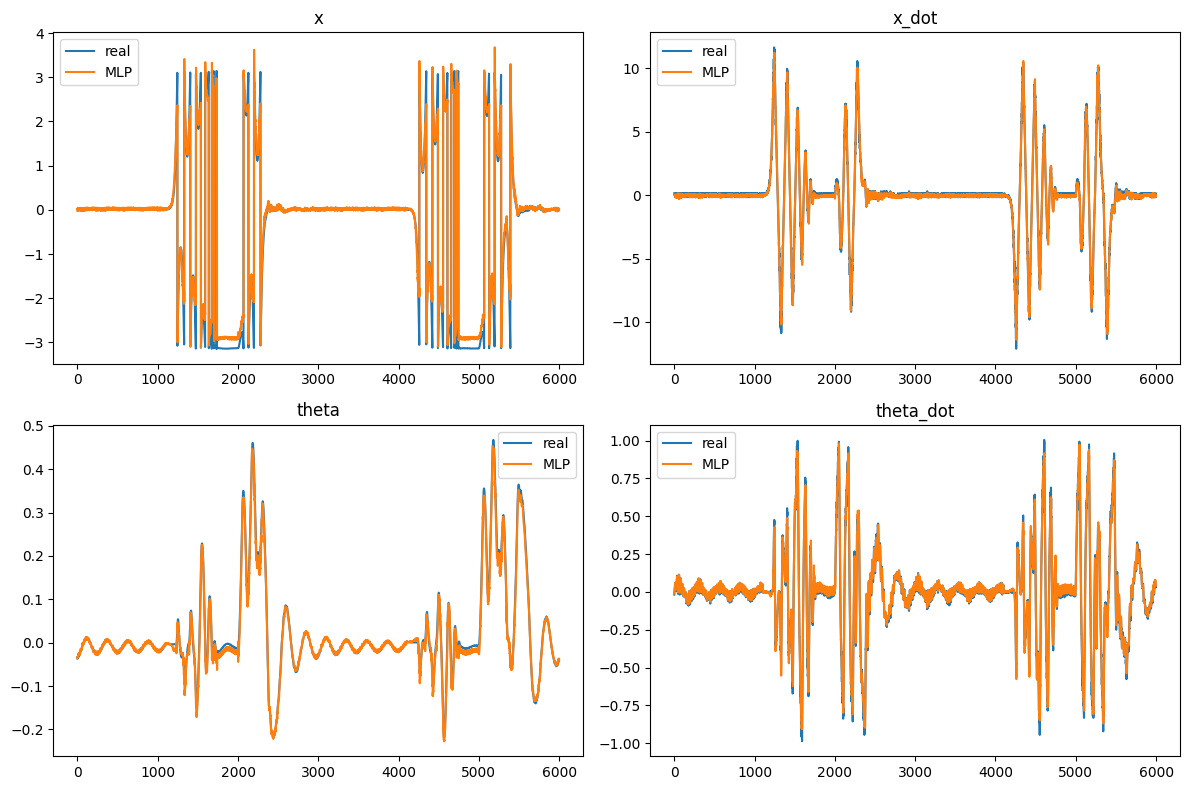

In [3]:
from sklearn.neural_network import MLPRegressor

# =========================
# MODELO MLP
# =========================
mlp = MLPRegressor(
    hidden_layer_sizes=(32,32),
    activation='relu',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, Y_train)

Y_pred_mlp = mlp.predict(X_test)

mse_mlp = mean_squared_error(Y_test, Y_pred_mlp)
print("MSE MLP:", mse_mlp)

# desnormalizar
Y_pred_real_mlp = sy.inverse_transform(Y_pred_mlp)

# plot
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(Y_test_real[:,i], label="real")
    plt.plot(Y_pred_real_mlp[:,i], label="MLP")
    plt.title(labels[i])
    plt.legend()

plt.tight_layout()
plt.show()